In [1]:
from dataset import DGDCountDataset

dataset = DGDCountDataset(
    root_dir="./data",
    ann_file="./data/FSC147/annotation_FSC147_384.json",
    class_file="./data/FSC147/ImageClasses_FSC147.txt",
    split_file="./data/FSC147/Train_Test_Val_FSC_147.json",
    split='train',
    target_size=384,
    normalize=None
)
print(dataset.__len__())

d:\conda_envs\zsc\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


3659


In [2]:
dataset.__getitem__(0)

ratio w - h: 1.0 1.0


{'images': tensor([[[ 0.3725,  0.2784,  0.1922,  ..., -0.0824, -0.0275,  0.0275],
          [ 0.2471,  0.2471,  0.3020,  ...,  0.0667,  0.0745,  0.1059],
          [ 0.2157,  0.1608,  0.1294,  ...,  0.0275,  0.0196,  0.0353],
          ...,
          [ 0.2627,  0.3098,  0.3333,  ...,  0.4824,  0.4824,  0.4824],
          [ 0.2314,  0.2941,  0.3255,  ...,  0.5608,  0.5608,  0.5765],
          [ 0.4039,  0.4510,  0.4275,  ...,  0.5451,  0.5216,  0.5294]],
 
         [[ 0.1843,  0.0902, -0.0039,  ..., -0.2863, -0.2314, -0.1765],
          [ 0.0588,  0.0588,  0.1059,  ..., -0.1373, -0.1294, -0.0980],
          [ 0.0275, -0.0275, -0.0667,  ..., -0.1922, -0.2000, -0.1843],
          ...,
          [ 0.0431,  0.0902,  0.1137,  ...,  0.2627,  0.2627,  0.2627],
          [ 0.0118,  0.0745,  0.1059,  ...,  0.3333,  0.3333,  0.3490],
          [ 0.1843,  0.2314,  0.2078,  ...,  0.3176,  0.2941,  0.3020]],
 
         [[-0.0824, -0.1765, -0.2471,  ..., -0.5765, -0.5216, -0.4667],
          [-0.2078

ratio w - h: 1.0 0.75


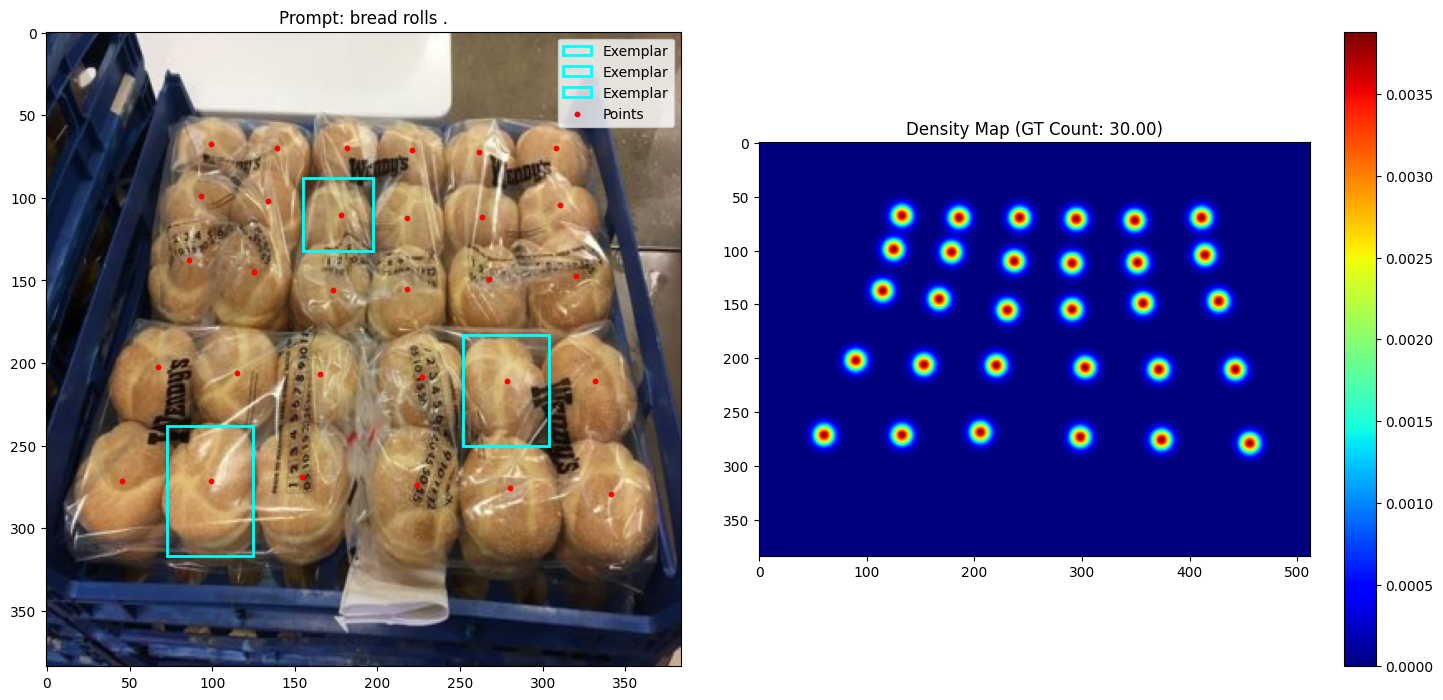

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import numpy as np

def visualize_sample(sample):
    # 1. Xử lý ảnh: Chuyển từ Tensor (C, H, W) dải [-1, 1] sang Numpy (H, W, C) dải [0, 1]
    img_tensor = sample['images']
    # Đảo ngược normalization: img * std + mean
    img_tensor = img_tensor * 0.5 + 0.5 
    # Chuyển kênh: (3, 384, 384) -> (384, 384, 3)
    img_numpy = img_tensor.permute(1, 2, 0).numpy()
    img_numpy = np.clip(img_numpy, 0, 1) # Đảm bảo nằm trong dải [0, 1] để không bị lỗi hiển thị

    # 2. Lấy dữ liệu points và exemplars
    points = sample['points'].numpy()      # Shape (M, 2) -> [x, y]
    exemplars = sample['exemplars'].numpy() # Shape (N, 4) -> [x1, y1, x2, y2]
    prompt = sample['prompts']
    den_map = sample['den_map'].numpy()

    # 3. Vẽ biểu đồ
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))

    # --- Subplot 1: Ảnh gốc + Bboxes + Points ---
    ax[0].imshow(img_numpy)
    ax[0].set_title(f"Prompt: {prompt}")

    # Vẽ Exemplar Boxes (Hình chữ nhật)
    for box in exemplars:
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        # Lưu ý: patches.Rectangle nhận (x_min, y_min)
        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='cyan', facecolor='none', label='Exemplar')
        ax[0].add_patch(rect)

    # Vẽ Points (Dấu chấm)
    if len(points) > 0:
        ax[0].scatter(points[:, 0], points[:, 1], c='red', s=10, label='Points')
    
    ax[0].legend(loc='upper right')

    # --- Subplot 2: Density Map (Bản đồ mật độ) ---
    im2 = ax[1].imshow(den_map, cmap='jet')
    ax[1].set_title(f"Density Map (GT Count: {den_map.sum():.2f})")
    plt.colorbar(im2, ax=ax[1])

    plt.tight_layout()
    plt.show()

# --- Cách sử dụng ---
sample = dataset.__getitem__(5)
visualize_sample(sample)

In [3]:
import numpy as np
pic1 = np.load("data/gt_density_map_adaptive_384_VarV2/2.npy", allow_pickle=True)
print(pic1.shape)

(384, 633)
